## Сравнительный анализ различных методов регрессии

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("DATA/rock_density_xray.csv")

In [4]:
df.head()

,Rebound Signal Strength nHz,Rock Density kg/m3
0,72.945124,2.456548
1,14.229877,2.601719
2,36.597334,1.967004
3,9.578899,2.300439
4,21.765897,2.452374


In [5]:
df.columns=['Signal',"Density"]

<Axes: xlabel='Signal', ylabel='Density'>

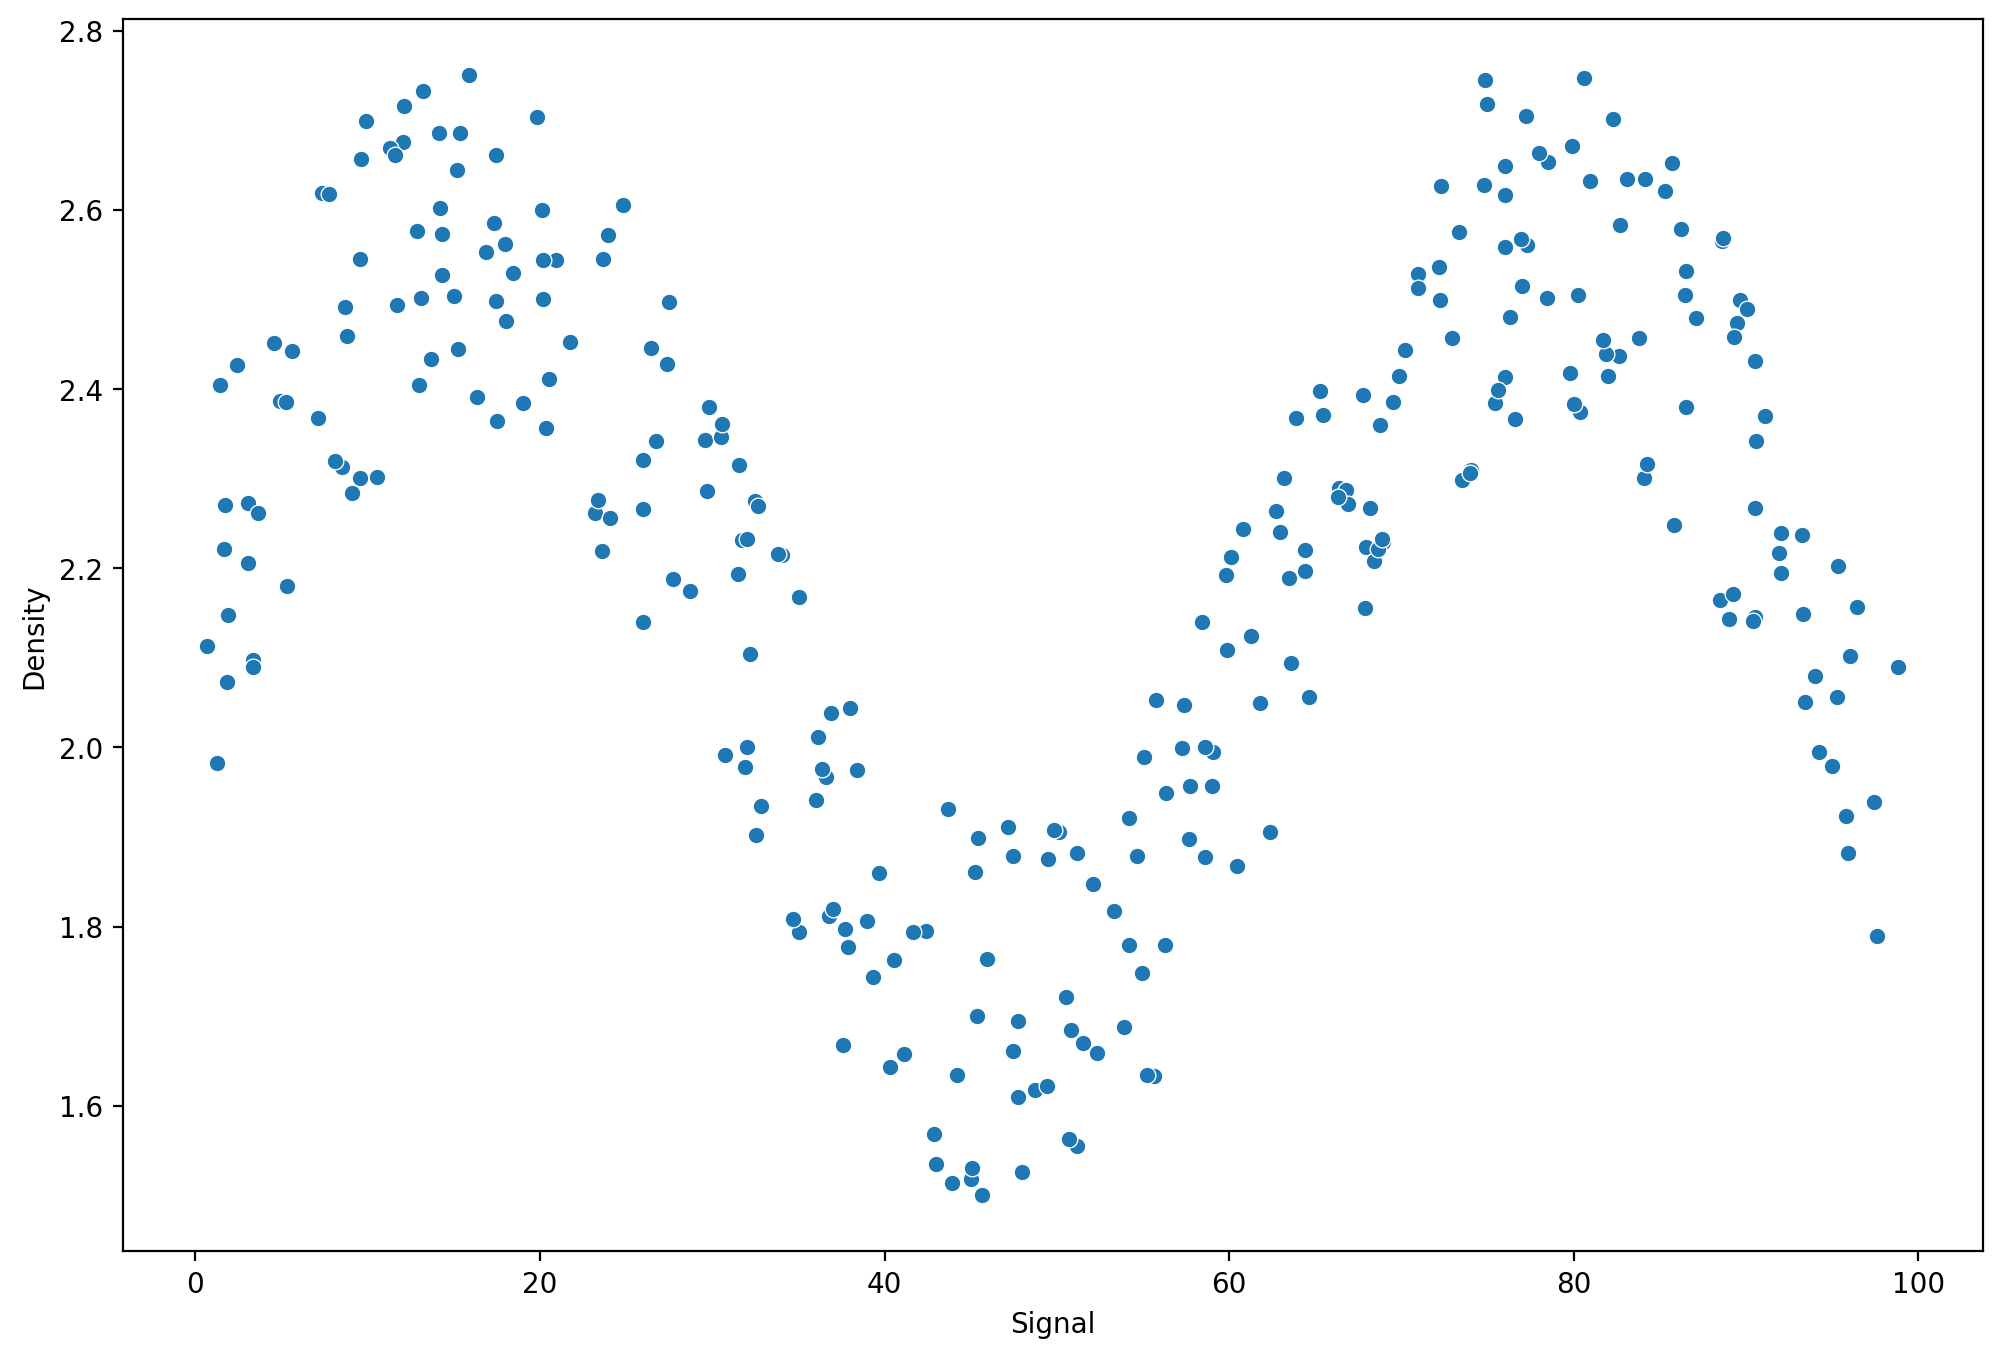

In [6]:
plt.figure(figsize=(12,8),dpi=200)
sns.scatterplot(x='Signal',y='Density',data=df)

---
---

## Разбиение данных на обучающий и тестовый наборы 

Разбиение нужно для последующей оценки модели на тестовом наборе данных.

In [7]:
X = df['Signal'].values.reshape(-1,1)  
y = df['Density']

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

-----

# Линейная регрессия

In [10]:
from sklearn.linear_model import LinearRegression

In [11]:
lr_model = LinearRegression()

In [12]:
lr_model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [13]:
lr_preds = lr_model.predict(X_test)

In [14]:
from sklearn.metrics import mean_squared_error

In [15]:
np.sqrt(mean_squared_error(y_test,lr_preds))

np.float64(0.25700519965846286)

In [16]:
signal_range = np.arange(0,100)

In [17]:
lr_output = lr_model.predict(signal_range.reshape(-1,1))

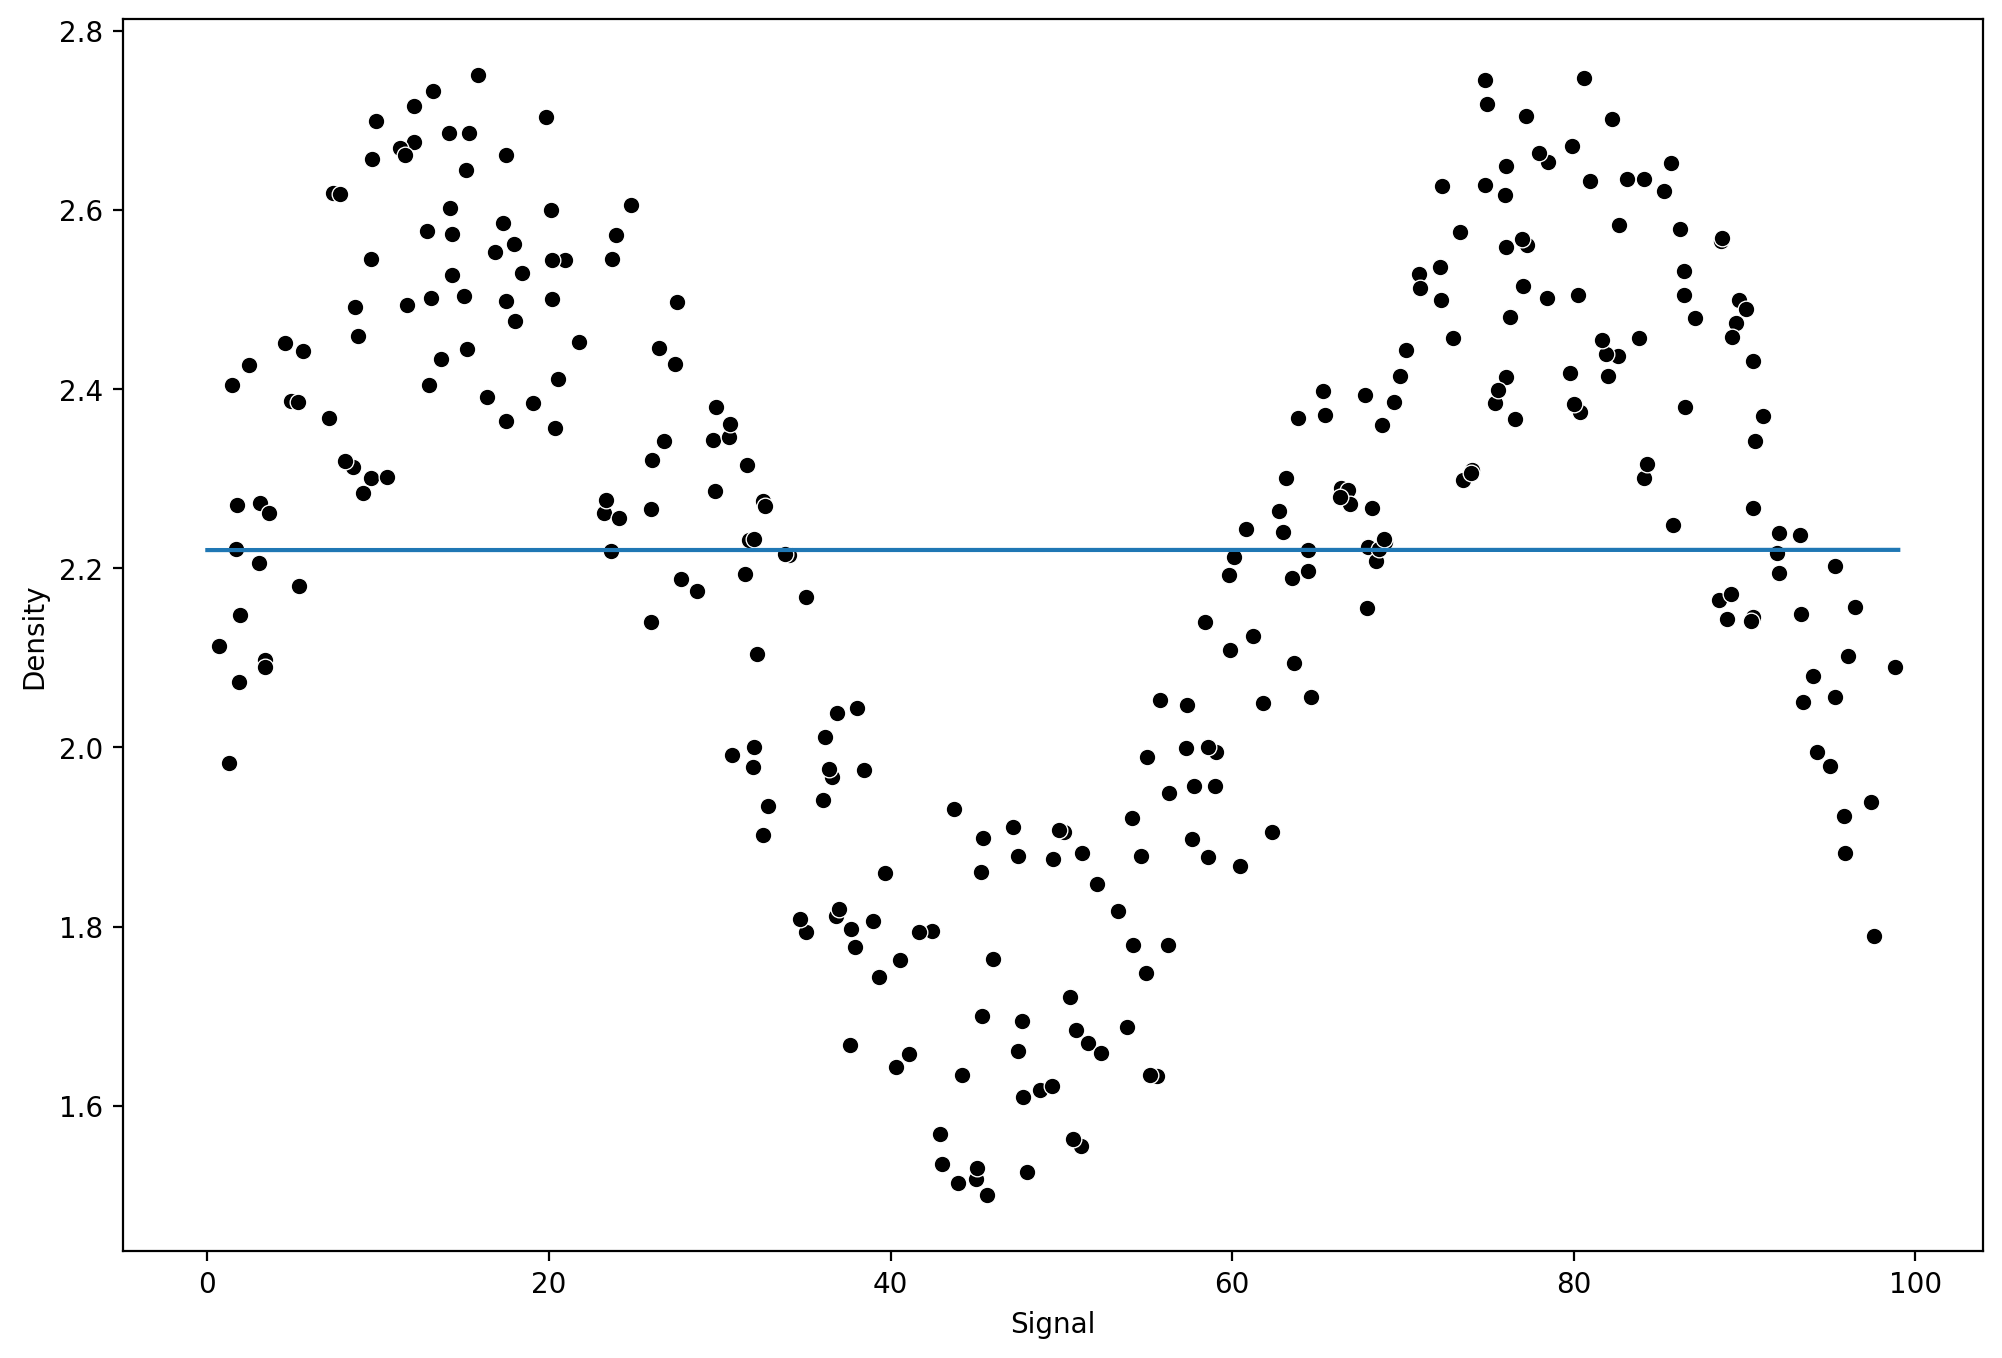

In [18]:
plt.figure(figsize=(12,8),dpi=200)
sns.scatterplot(x='Signal',y='Density',data=df,color='black')
plt.plot(signal_range,lr_output)

---

# Полиномиальная регрессия

## Попытка применить модель полиномиальной регрессии

Посмотрим, почему стандартный подход полиномиальной модели здесь будет затруднителен. 

## Вспомогательная функция для запуска моделей

In [19]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [20]:
def run_model(model,X_train,y_train,X_test,y_test):
    
    model.fit(X_train,y_train)
    
    
    preds = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test,preds))
    print(f'RMSE : {rmse}')
    
    signal_range = np.arange(0,100)
    output = model.predict(signal_range.reshape(-1,1))
    
    
    plt.figure(figsize=(12,6),dpi=150)
    sns.scatterplot(x='Signal',y='Density',data=df,color='black')
    plt.plot(signal_range,output)

RMSE : 0.25700519965846286


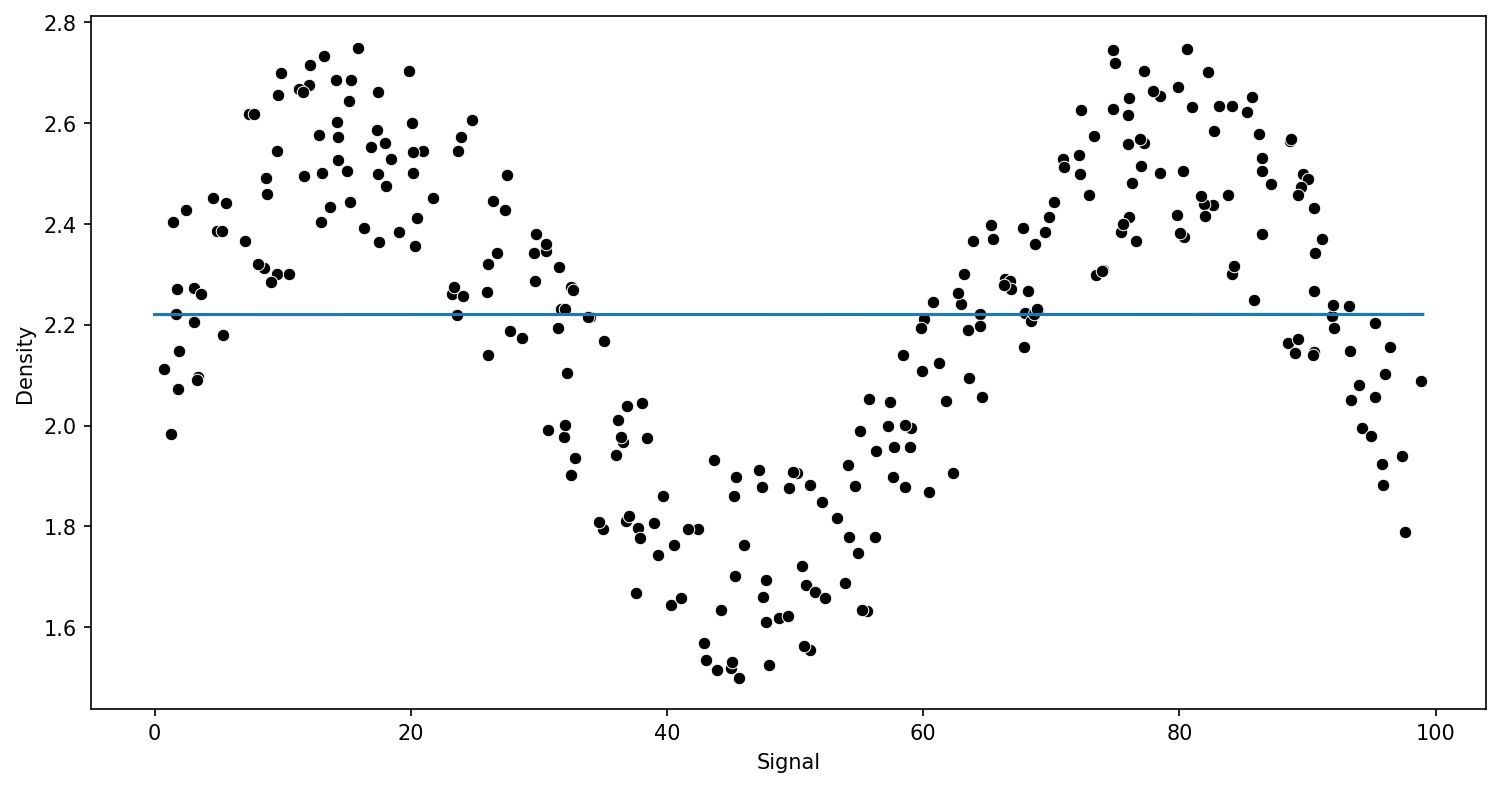

In [21]:
run_model(model,X_train,y_train,X_test,y_test)

## Пайплайн для степеней полинома

In [22]:
from sklearn.pipeline import make_pipeline

In [23]:
from sklearn.preprocessing import PolynomialFeatures

In [24]:
pipe = make_pipeline(PolynomialFeatures(2),LinearRegression())

RMSE : 0.2817309563725552


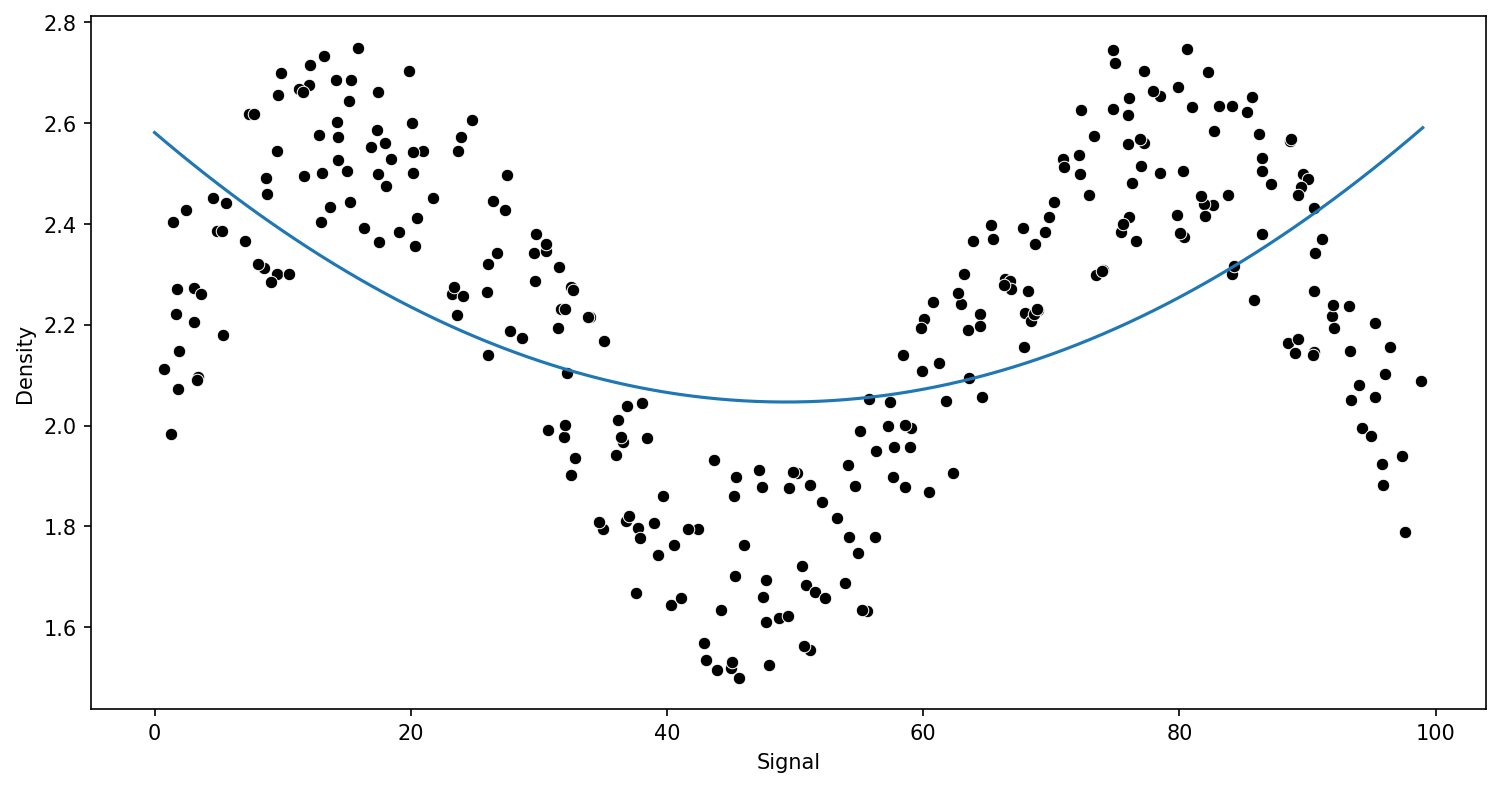

In [25]:
run_model(pipe,X_train,y_train,X_test,y_test)

## Сравнение различных степеней полинома

RMSE : 0.16269005292916663


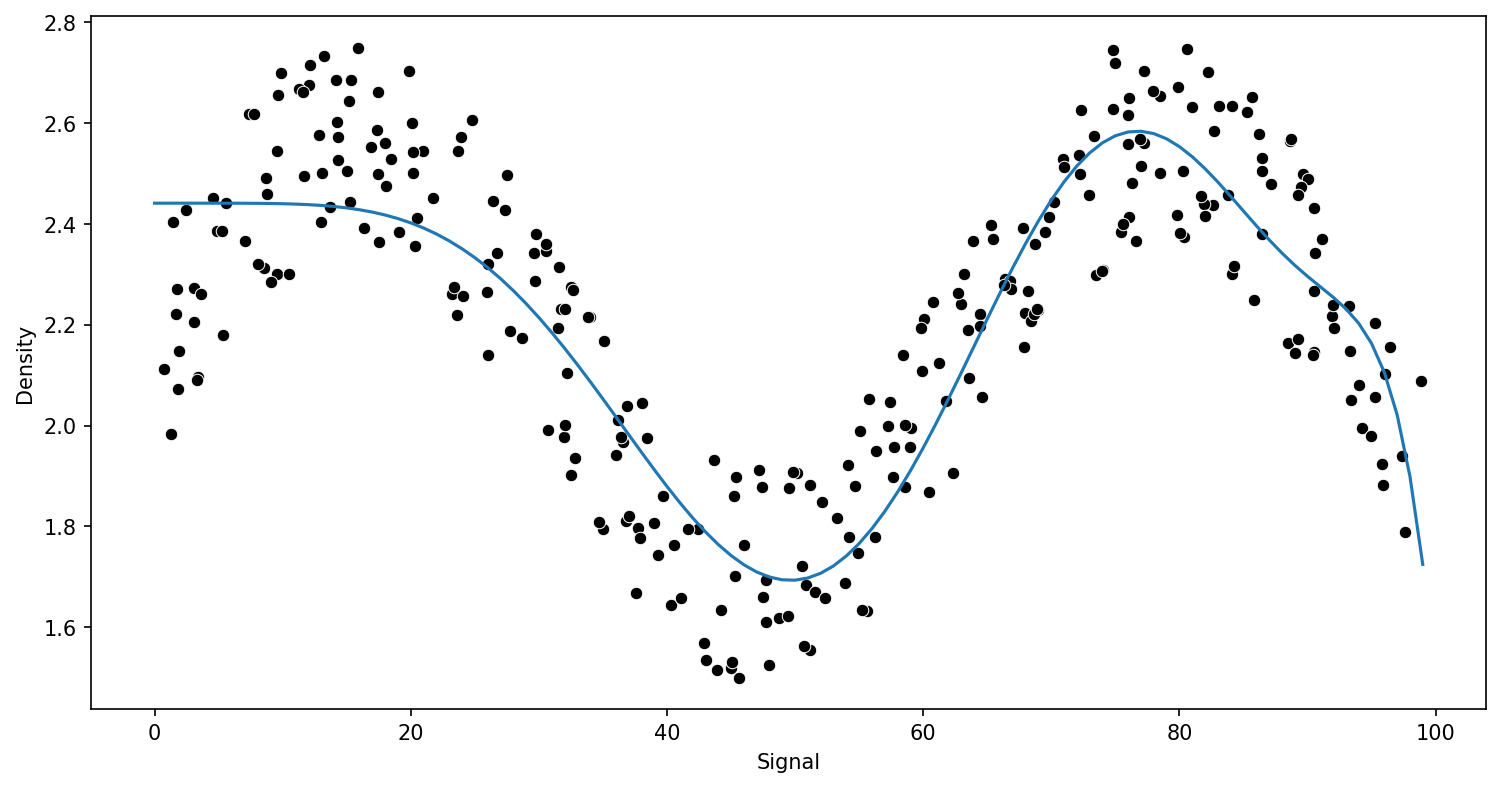

In [26]:
pipe = make_pipeline(PolynomialFeatures(10),LinearRegression())
run_model(pipe,X_train,y_train,X_test,y_test)

----

## Регрессия KNN 

In [27]:
from sklearn.neighbors import KNeighborsRegressor

RMSE : 0.15234870286353372
RMSE : 0.13730685016923658
RMSE : 0.13277855732740923


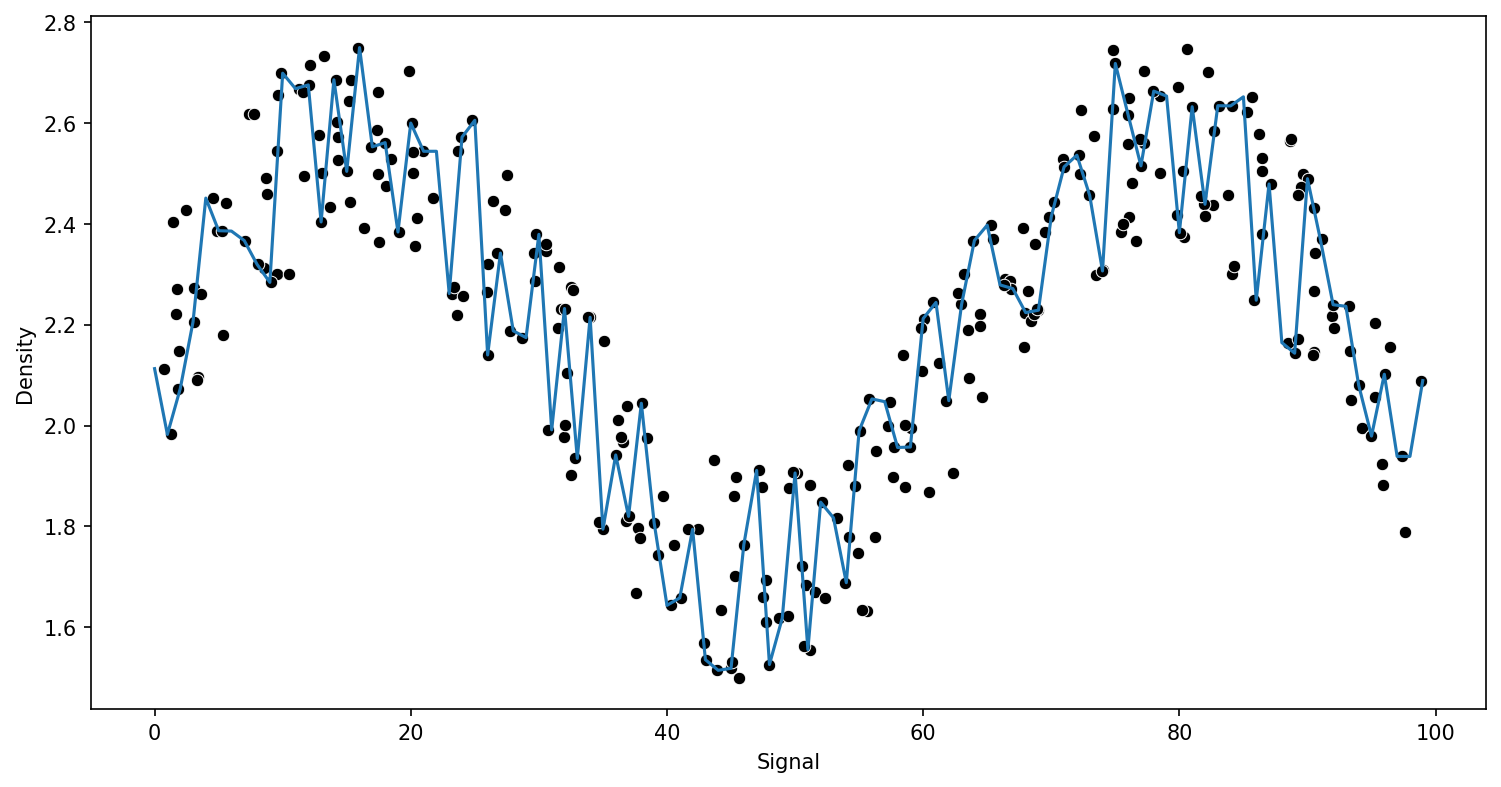

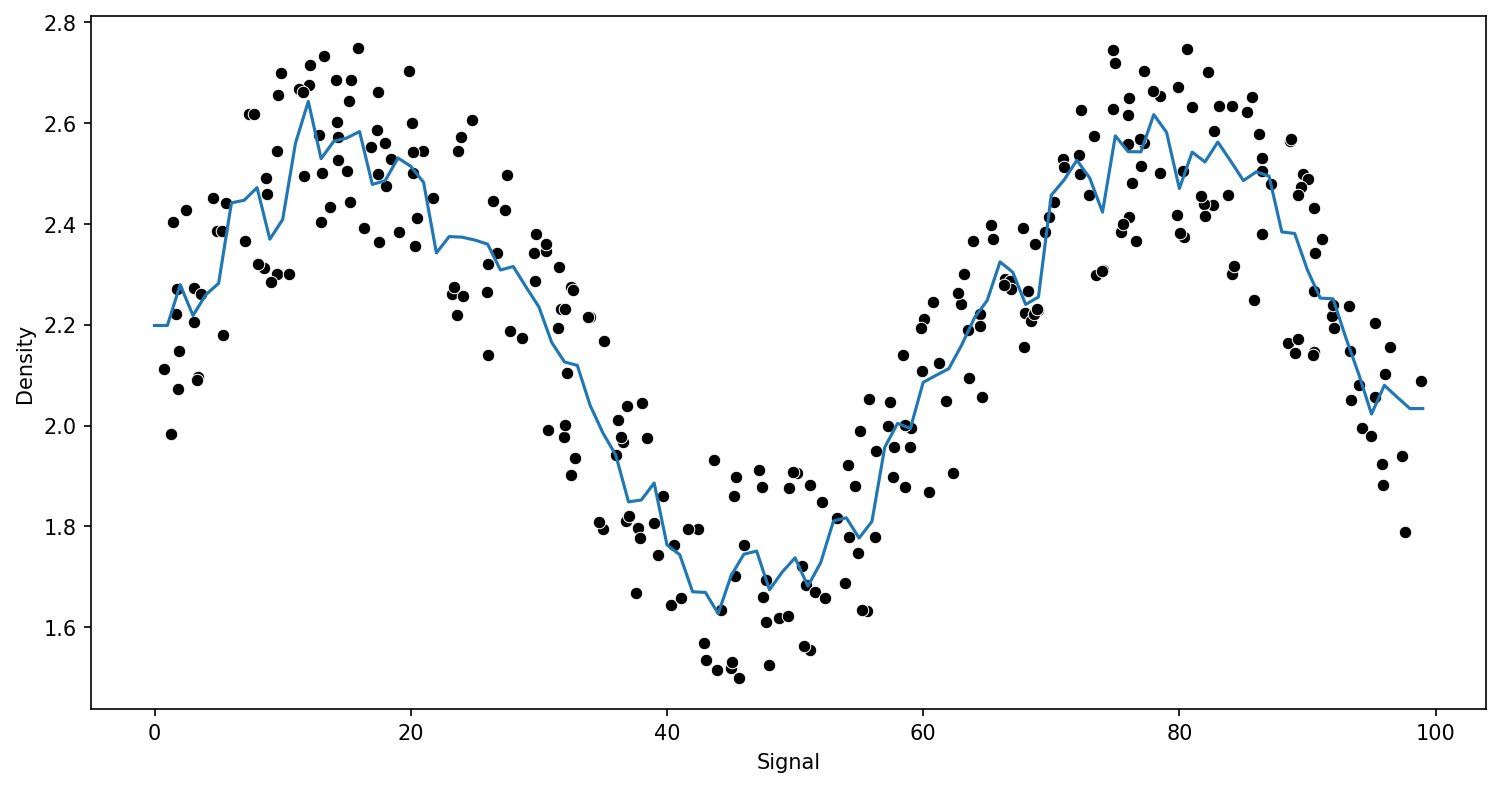

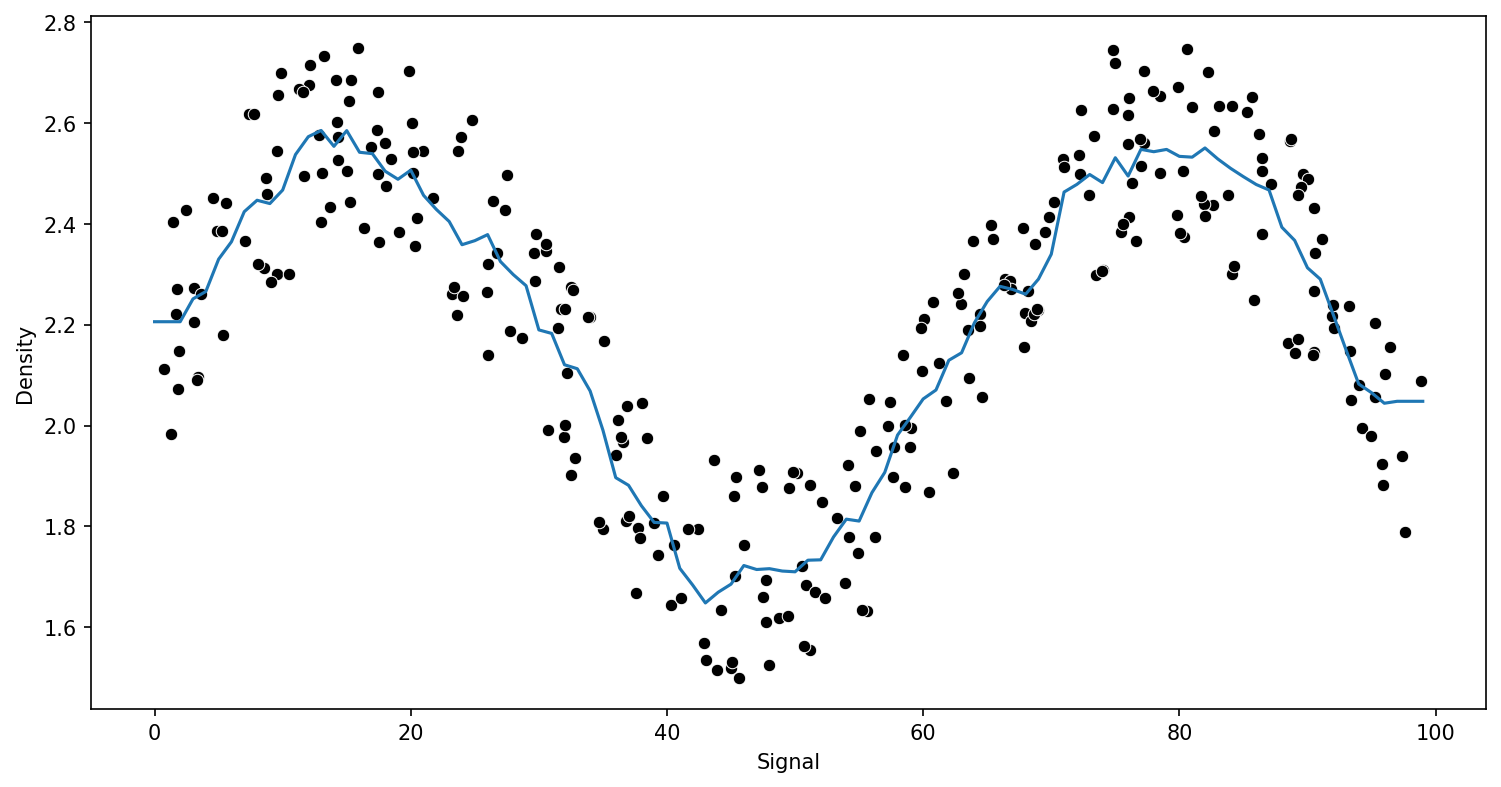

In [28]:
preds = {}
k_values = [1,5,10]
for n in k_values:    
    model = KNeighborsRegressor(n_neighbors=n)
    run_model(model,X_train,y_train,X_test,y_test)

---
## Деревья решений для регрессии

In [29]:
from sklearn.tree import DecisionTreeRegressor

RMSE : 0.15234870286353372


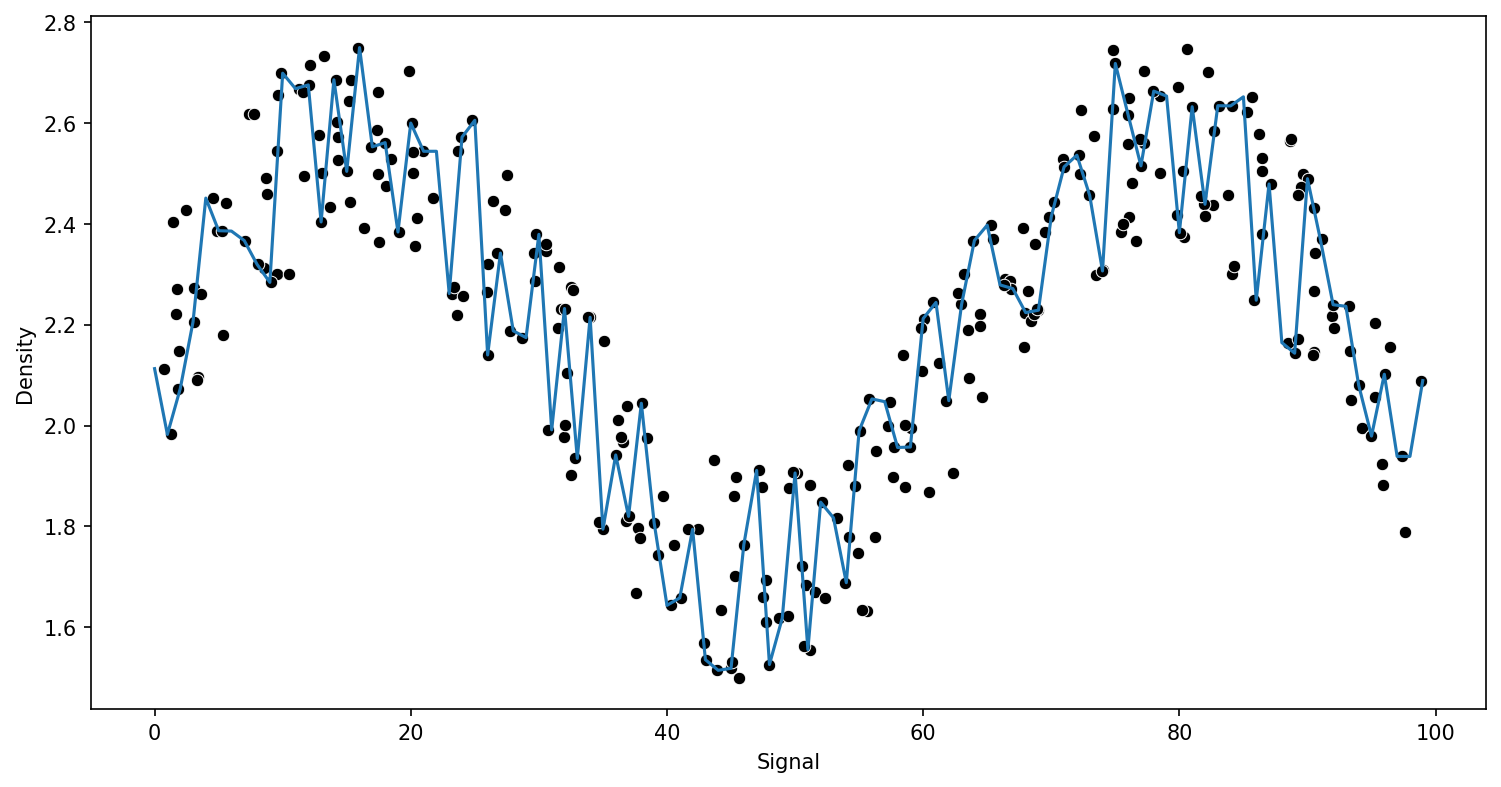

In [30]:
model = DecisionTreeRegressor()

run_model(model,X_train,y_train,X_test,y_test)

In [31]:
model.get_n_leaves()

np.int64(270)

----

## Метод опорных векторов для регрессии

In [32]:
from sklearn.svm import SVR

In [33]:
from sklearn.model_selection import GridSearchCV

In [34]:
param_grid = {'C':[0.01,0.1,1,5,10,100,1000],'gamma':['auto','scale']}
svr = SVR()

In [35]:
grid = GridSearchCV(svr,param_grid)

RMSE : 0.1263507854819897


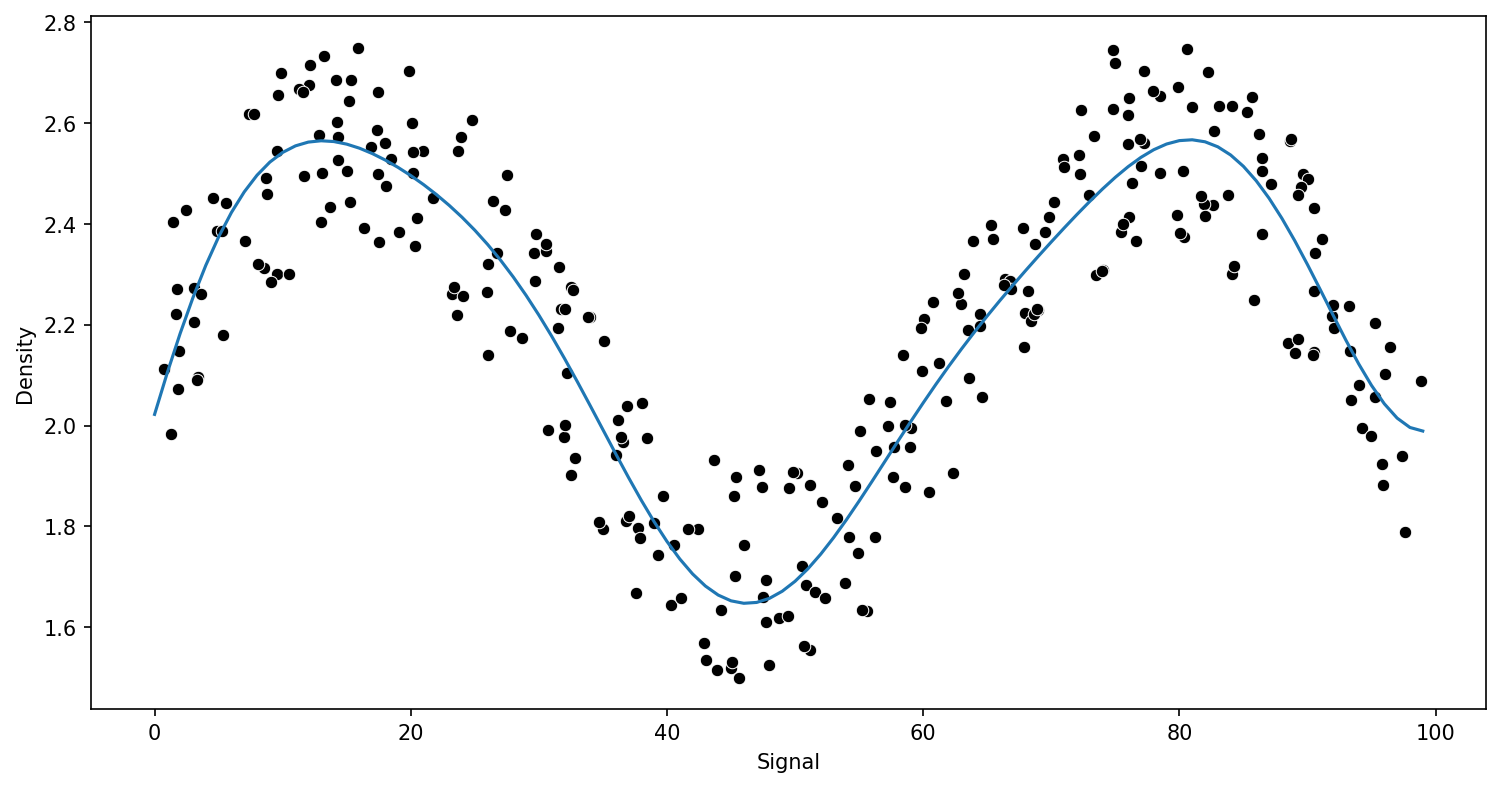

In [36]:
run_model(grid,X_train,y_train,X_test,y_test)

In [37]:
grid.best_estimator_

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1000
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


---

## Случайные леса для регрессии

In [38]:
from sklearn.ensemble import RandomForestRegressor

RMSE : 0.13258000078798357
RMSE : 0.13838144633556157
RMSE : 0.135317772958429


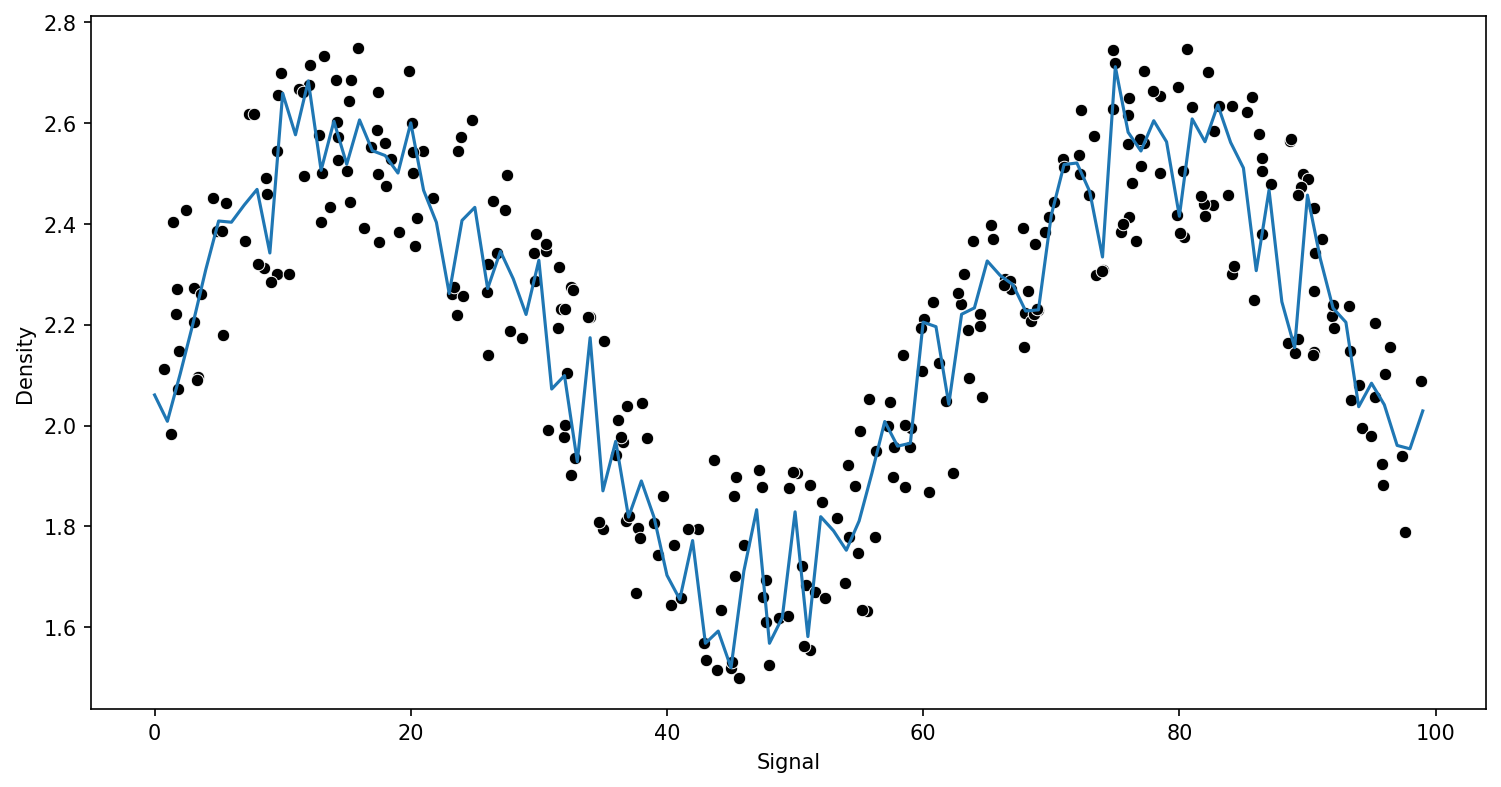

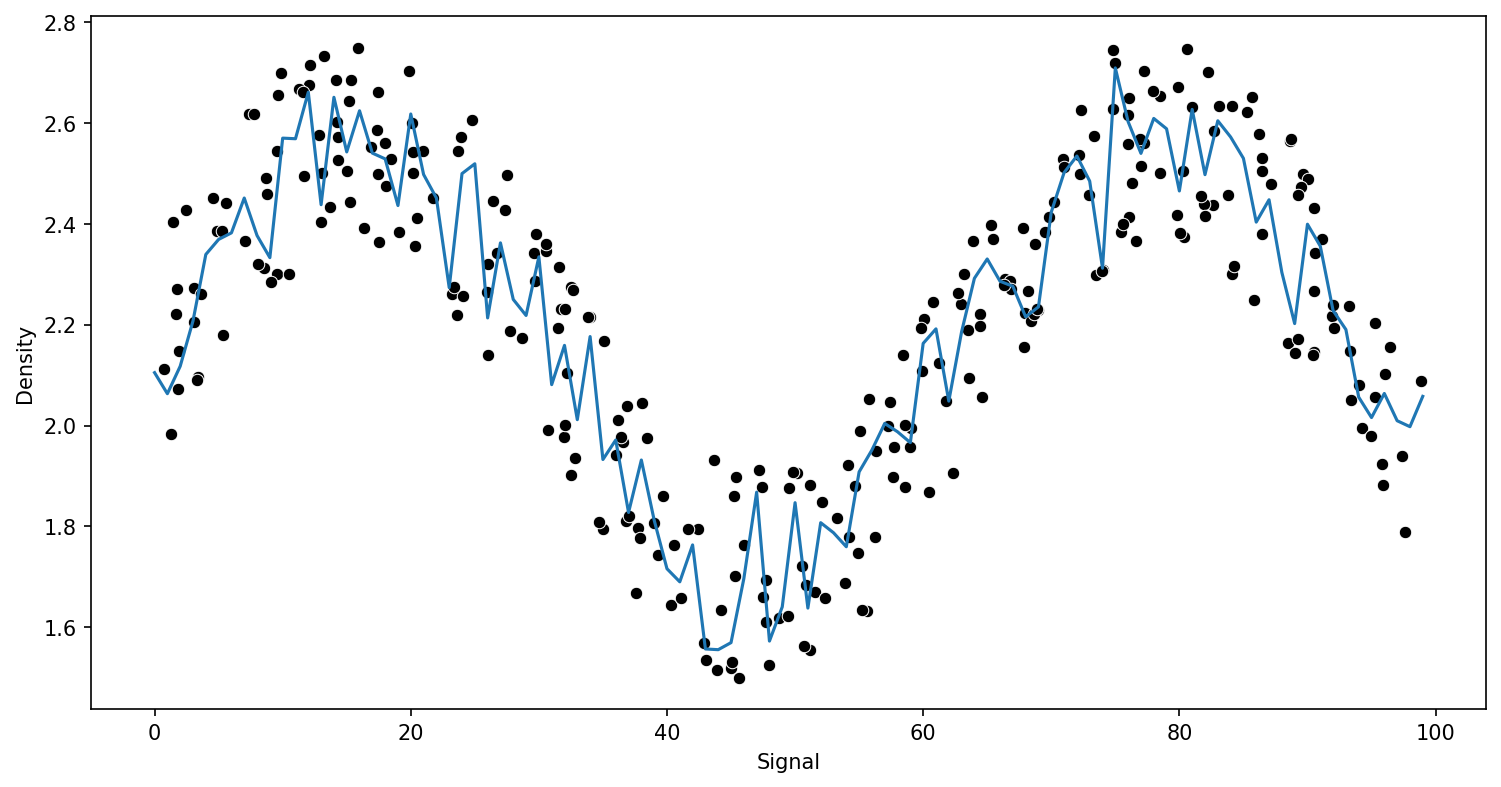

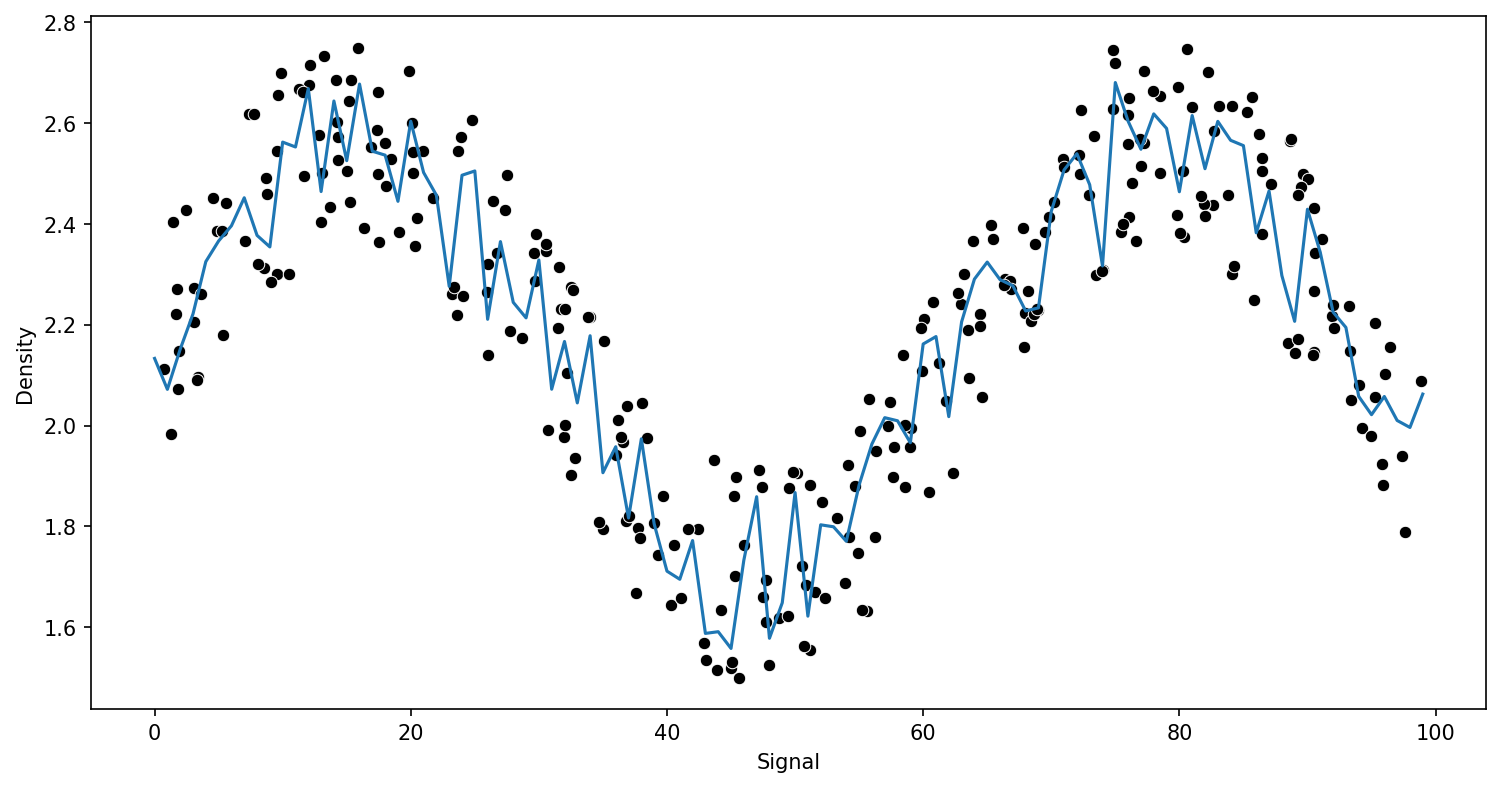

In [39]:
trees = [10,50,100]
for n in trees:
    
    model = RandomForestRegressor(n_estimators=n)
    
    run_model(model,X_train,y_train,X_test,y_test)

## Градиентный бустинг


In [40]:
from sklearn.ensemble import GradientBoostingRegressor

RMSE : 0.13294148649584664


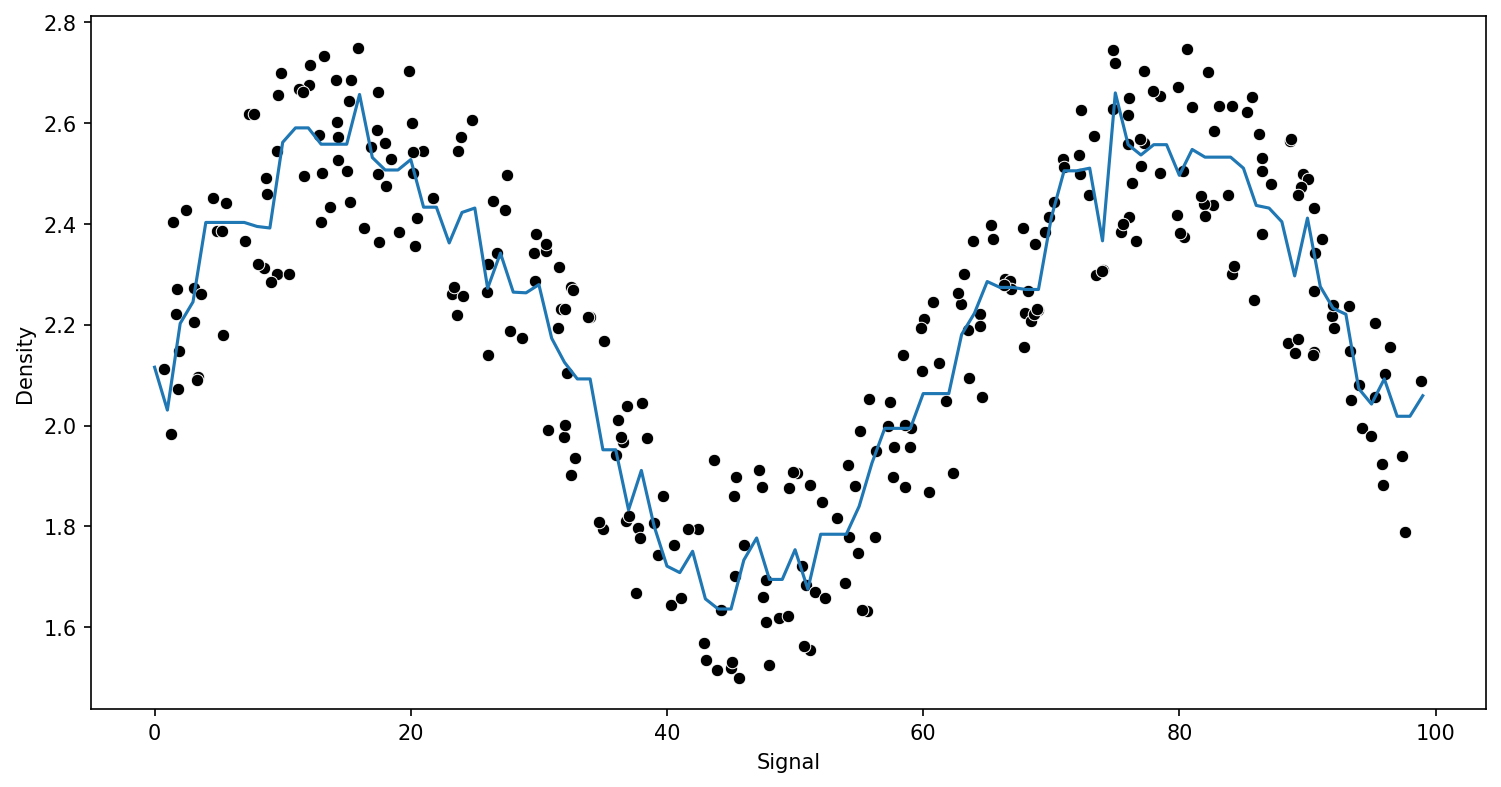

In [41]:
   
model = GradientBoostingRegressor()

run_model(model,X_train,y_train,X_test,y_test)

## Adaboost

In [42]:
from sklearn.ensemble import AdaBoostRegressor

RMSE : 0.13294148649584664


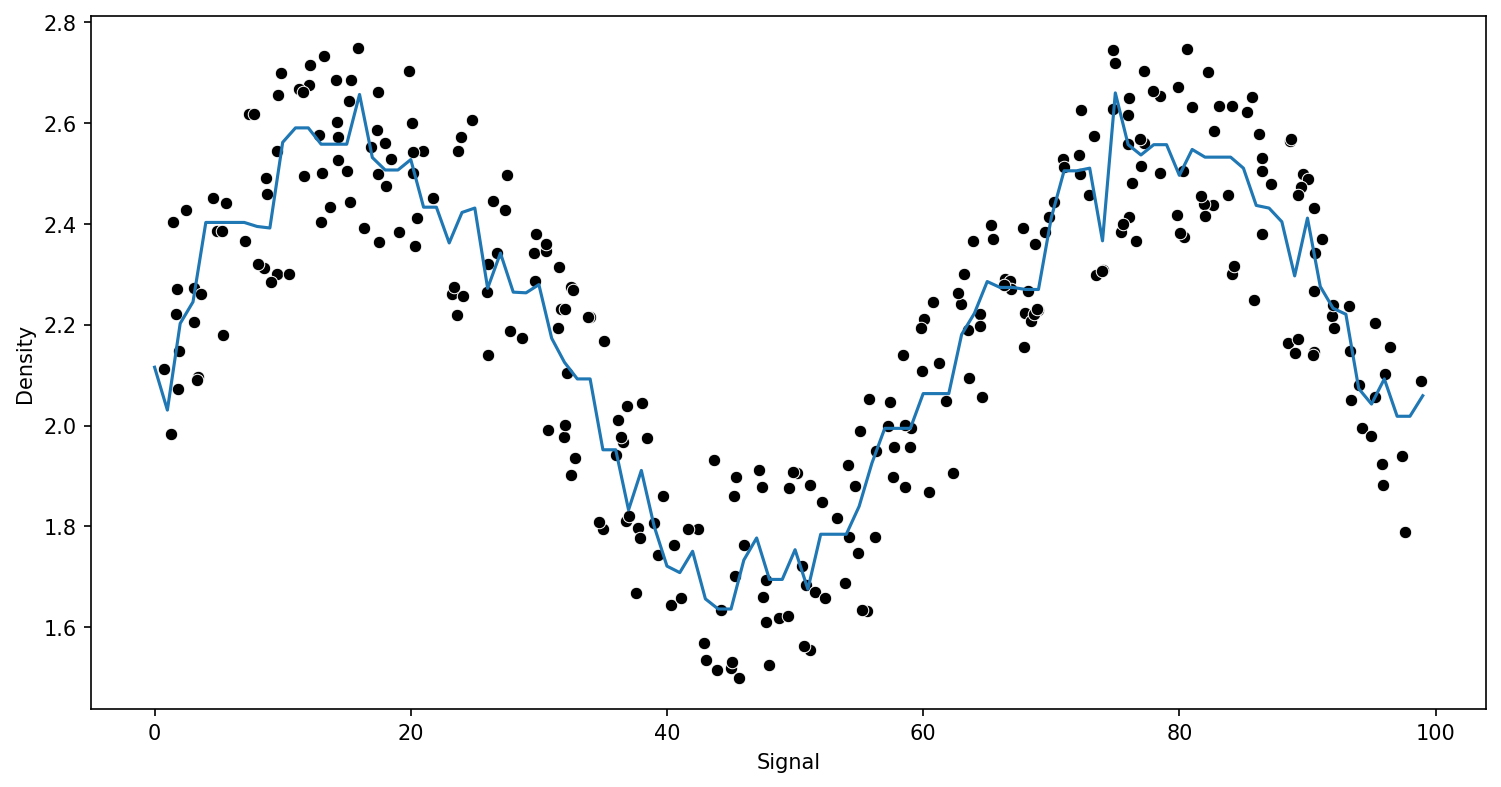

In [43]:
model = GradientBoostingRegressor()

run_model(model,X_train,y_train,X_test,y_test)